In [0]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv")

spark_df = spark.createDataFrame(df)
spark_df.show(5)

missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

df_cleaned = df.dropna()
print(df_cleaned)


+---+---------+-----------------+---------+--------------------+----------------+-------------+--------------+-----------------------+------+----------+--------------+------------+--------------------+---------------+-------------+-------------+-----------+------------------+--------+-----------------+-----------------+------------------------+----------------+-----------------+---------------------+---------------+--------------+------------------+-----------------------+--------------------+
|Age|Attrition|   BusinessTravel|DailyRate|          Department|DistanceFromHome|    Education|EducationField|EnvironmentSatisfaction|Gender|HourlyRate|JobInvolvement|    JobLevel|             JobRole|JobSatisfaction|MaritalStatus|MonthlyIncome|MonthlyRate|NumCompaniesWorked|OverTime|PercentSalaryHike|PerformanceRating|RelationshipSatisfaction|StockOptionLevel|TotalWorkingYears|TrainingTimesLastYear|WorkLifeBalance|YearsAtCompany|YearsInCurrentRole|YearsSinceLastPromotion|YearsWithCurrManager|
+-

In [0]:

the output
+---+---------+--------------------+-------------+--------------------+
|Age|Attrition|          Department|MonthlyIncome|             JobRole|
+---+---------+--------------------+-------------+--------------------+
| 41|      Yes|               Sales|         5993|     Sales Executive|
| 49|       No|Research & Develo...|         5130|  Research Scientist|
| 37|      Yes|Research & Develo...|         2090|Laboratory Techni...|
| 33|       No|Research & Develo...|         2909|  Research Scientist|
| 27|       No|Research & Develo...|         3468|Laboratory Techni...|
+---+---------+--------------------+-------------+--------------------+

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   object
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   object
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   object
 12  JobLevel                  1470 non-null   object
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [0]:
label_encoders = {}
for i in df.columns:
  if df[i].dtypes == 'object':
      le = LabelEncoder()
      df[i] = le.fit_transform(df[i])
      label_encoders[i] = le
  print(df.head())

   Age Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   41       Yes  ...                       0                     5
1   49        No  ...                       1                     7
2   37       Yes  ...                       0                     0
3   33        No  ...                       3                     0
4   27        No  ...                       2                     2

[5 rows x 31 columns]
   Age  Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   41          1  ...                       0                     5
1   49          0  ...                       1                     7
2   37          1  ...                       0                     0
3   33          0  ...                       3                     0
4   27          0  ...                       2                     2

[5 rows x 31 columns]
   Age  Attrition  ...  YearsSinceLastPromotion  YearsWithCurrManager
0   41          1  ...                        0               

### Attrition Distribution

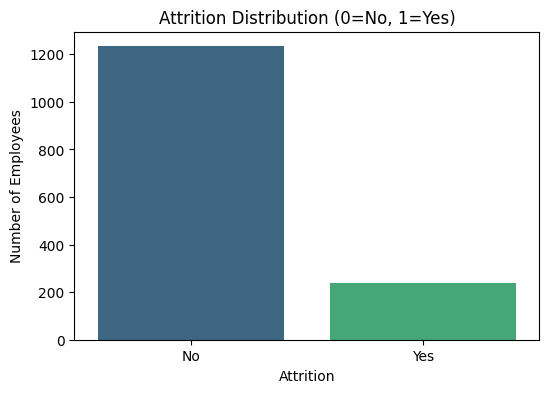

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='viridis')
plt.title('Attrition Distribution (0=No, 1=Yes)')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

### Salary vs Performance

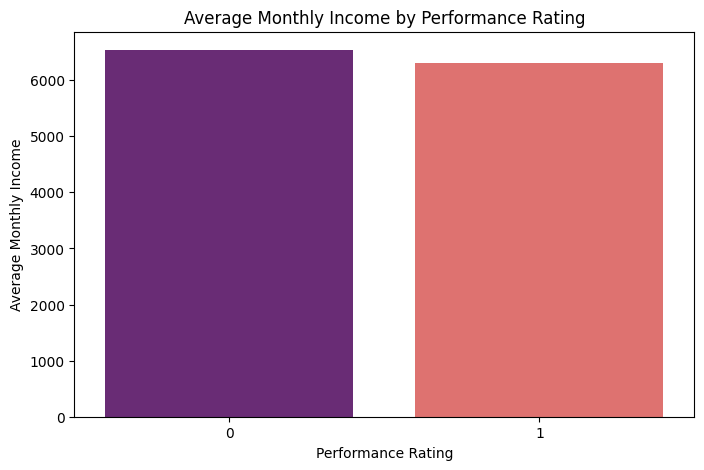

In [0]:
avg_salary_by_performance = df.groupby('PerformanceRating')['MonthlyIncome'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='PerformanceRating', y='MonthlyIncome', data=avg_salary_by_performance, palette='magma')
plt.title('Average Monthly Income by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Average Monthly Income')
plt.show()

### Department Insights

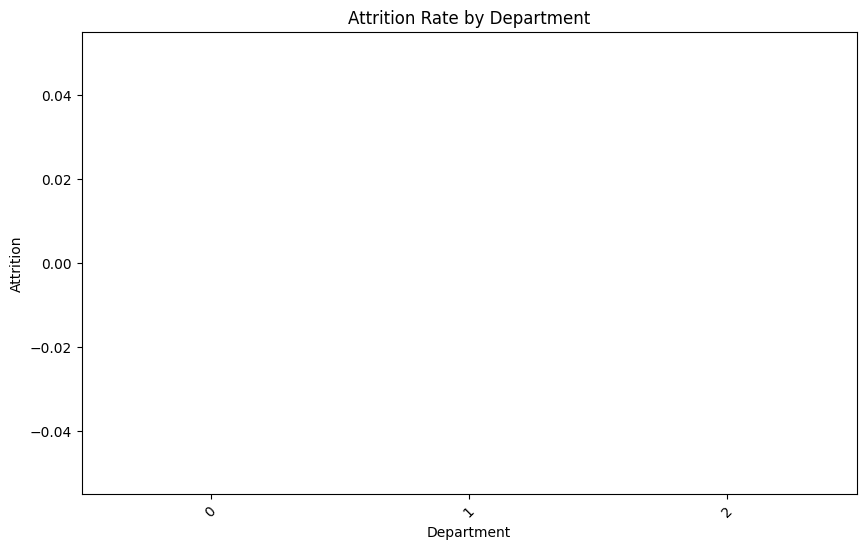

In [0]:
# convert to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# groupby
attrition_by_department = df.groupby('Department')['Attrition'].mean().reset_index()

# plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='Attrition', data=attrition_by_department, palette='cividis')
plt.title('Attrition Rate by Department')
plt.xticks(rotation=45)
plt.show()

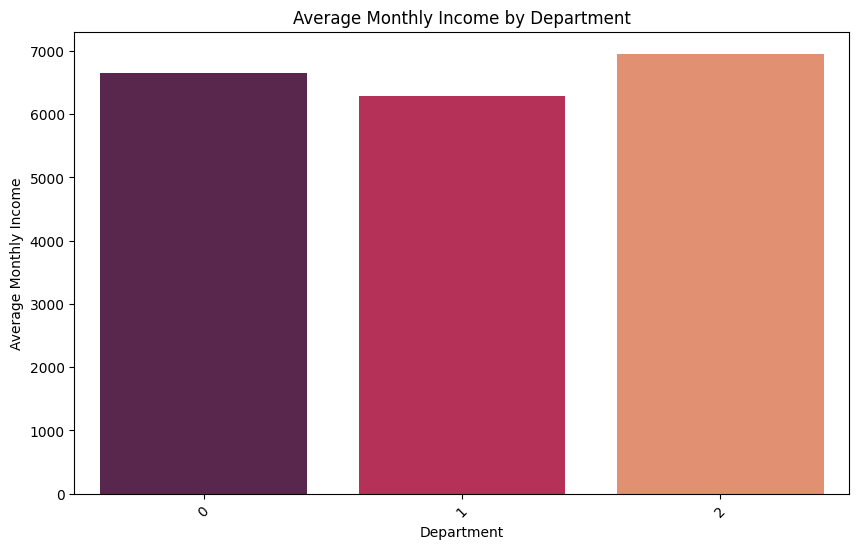

In [0]:
avg_income_by_department = df.groupby('Department')['MonthlyIncome'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='MonthlyIncome', data=avg_income_by_department, palette='rocket')
plt.title('Average Monthly Income by Department')
plt.xlabel('Department')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45)
plt.show()

### Feature Engineering

In [0]:
df['JobSatisfaction'] = pd.factorize(df['JobSatisfaction'])[0]
df['WorkLifeBalance'] = pd.factorize(df['WorkLifeBalance'])[0]
df['EnvironmentSatisfaction'] = pd.factorize(df['EnvironmentSatisfaction'])[0]
df['JobInvolvement'] = pd.factorize(df['JobInvolvement'])[0]
df['PerformanceRating'] = pd.factorize(df['PerformanceRating'])[0]


df['Engagement'] = df['JobSatisfaction'] + df['WorkLifeBalance'] + df['EnvironmentSatisfaction'] + df['JobInvolvement']
df['Performance'] = df['PercentSalaryHike'] + df['TrainingTimesLastYear'] + df['PerformanceRating']

print(df[['Engagement', 'Performance']].head())

   Engagement  Performance
0           0           11
1           4           27
2           6           18
3           5           14
4           5           15


### Model Development

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

df_clean = pd.read_csv("IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv")

df_encoded = df_clean.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop('Attrition', axis=1).select_dtypes(include=['number'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0)
model.fit(X_train, y_train)

print('Accuracy(train):{:.3f}'.format(model.score(X_train, y_train)))
print('Accuracy(test):{:.3f}'.format(model.score(X_test, y_test)))
print('F1 Score:{:.3f}'.format(f1_score(y_test, model.predict(X_test), average='macro')))

Accuracy(train):0.877
Accuracy(test):0.859
F1 Score:0.567


### Clustering

In [0]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Drop NaN values created during Spark conversion
df_encoded = df_encoded.dropna()

X = df_encoded.select_dtypes(include=['number'])

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=0)
df_encoded['Cluster'] = kmeans.fit_predict(X)

print('Cluster Distribution:')
print(df_encoded['Cluster'].value_counts())

/databricks/python/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff53b314b4c0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self

Cluster Distribution:
1    645
2    622
0    203
Name: Cluster, dtype: int64


In [0]:
from sklearn.metrics import f1_score, classification_report, mean_squared_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# Classification F1-Score
y_pred = model.predict(X_test)
print('=== Classification ===')
print('F1 Score:{:.3f}'.format(f1_score(y_test, y_pred, average='macro')))
print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

# Regression on MonthlyIncome
y_reg = df_encoded['MonthlyIncome']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, random_state=0)
reg_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)
reg_model.fit(X_train_reg, y_train_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, reg_model.predict(X_test_reg)))
print('=== Regression ===')
print('RMSE:{:.3f}'.format(rmse))

# Clustering Silhouette Score
print('\n=== Clustering ===')
print('Silhouette Score:{:.3f}'.format(silhouette_score(X, df_encoded['Cluster'])))

In [0]:
print('=== HR INSIGHTS ===')
print()
print('1. Attrition Rate by Cluster:')
print(df_encoded.groupby('Cluster')['Attrition'].mean().round(3))
print()
print('2. Average Monthly Income by Cluster:')
print(df_encoded.groupby('Cluster')['MonthlyIncome'].mean().round(0))
print()
print('3. High Risk Employees (Cluster 1 + Cluster 2 with Attrition=1):')
high_risk = df_encoded[(df_encoded['Cluster'].isin([1,2])) & (df_encoded['Attrition'] == 1)]
print('   Total:', len(high_risk))
print()
print('4. HR Strategies:')
print('   - Cluster 0: Retain top earners with leadership programs')
print('   - Cluster 1: Salary increase + career growth (highest risk)')
print('   - Cluster 2: Work-life balance + promotion opportunities (highest risk)')